# Import libraries and packages

In [1]:
import numpy as np
import re
import nltk
import pickle
from nltk.corpus import stopwords
import pandas as pd 
import warnings

# Data Exploration & Cleaning - 1

In [16]:
df= pd.read_csv("train.csv",encoding='latin-1')
df = df[0:1000]

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ItemID         1000 non-null   int64 
 1   Sentiment      1000 non-null   int64 
 2   SentimentText  1000 non-null   object
dtypes: int64(2), object(1)
memory usage: 23.6+ KB


In [18]:
df.head()

,ItemID,Sentiment,SentimentText
0,1,0,is so sad for my APL frie...
1,2,0,I missed the New Moon trail...
2,3,1,omg its already 7:30 :O
3,4,0,.. Omgaga. Im sooo im gunna CRy. I'...
4,5,0,i think mi bf is cheating on me!!! ...


In [19]:

df['message'] = df['SentimentText']
#df.drop(['Text Label','Tweet'],axis=1,inplace=True)

# Visualization

In [6]:
import seaborn as sns
sns.countplot(x="Sentiment", data = df)

<AxesSubplot:xlabel='Sentiment', ylabel='count'>

In [7]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [8]:
comment_words = ''
stopwords = set(STOPWORDS)

In [9]:
for val in df.message:
     
    # typecaste each val to string
    val = str(val)
 
    # split the value
    tokens = val.split()
     
    # Converts each token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()
     
    comment_words += " ".join(tokens)+" "

In [10]:
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(comment_words)

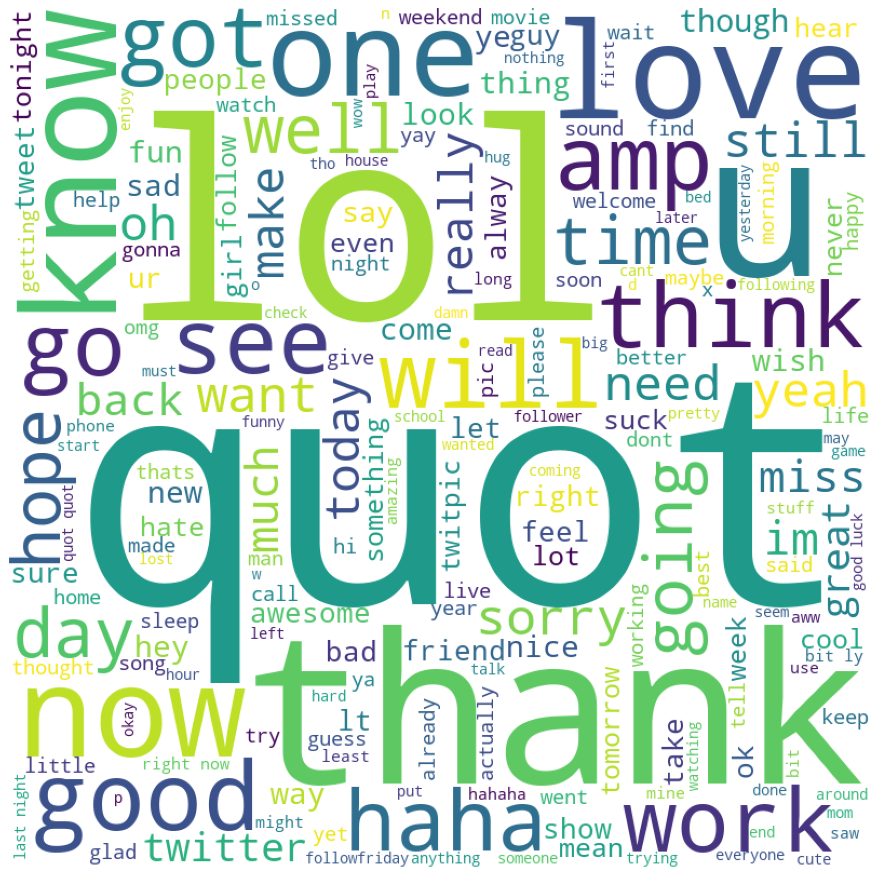

In [11]:
# plot the WordCloud image                      
plt.figure(figsize = (12, 12), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
 
plt.show()

# Feature Selection - Formal DAta

In [20]:
X = df['message']
y = df['Sentiment']

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Vectorizing the Sentence

In [22]:
cv = CountVectorizer()
X = cv.fit_transform(X) # Fit the Data

# Splitting Data

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [24]:
print(X_test.shape)
print(y_test.shape)

(330, 3451)
(330,)


# Machine Learning

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings

# Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression
LogisticR = LogisticRegression()
LogisticR.fit(X_train, y_train) 
y_pred = LogisticR.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
LR = accuracy_score(y_test, y_pred)

[[205  25]
 [ 69  31]]
              precision    recall  f1-score   support

           0       0.75      0.89      0.81       230
           1       0.55      0.31      0.40       100

    accuracy                           0.72       330
   macro avg       0.65      0.60      0.61       330
weighted avg       0.69      0.72      0.69       330

0.7151515151515152


# Random Forest Classifier

In [27]:
from sklearn.ensemble import RandomForestClassifier
RandomForest = RandomForestClassifier(n_estimators=10, random_state=0)
RandomForest.fit(X_train, y_train) 
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
RF = accuracy_score(y_test, y_pred)

[[205  25]
 [ 69  31]]
              precision    recall  f1-score   support

           0       0.75      0.89      0.81       230
           1       0.55      0.31      0.40       100

    accuracy                           0.72       330
   macro avg       0.65      0.60      0.61       330
weighted avg       0.69      0.72      0.69       330

0.7151515151515152


# AdaBoost Classifier

In [20]:
from sklearn.ensemble import AdaBoostClassifier
AdaBoost = AdaBoostClassifier(n_estimators=100, random_state=0)
AdaBoost.fit(X_train, y_train)
AdaBoostClassifier(n_estimators=100, random_state=0)
y_pred = AdaBoost.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
AB= accuracy_score(y_test, y_pred)

[[ 8038  6432]
 [ 3002 15525]]
              precision    recall  f1-score   support

           0       0.73      0.56      0.63     14470
           1       0.71      0.84      0.77     18527

    accuracy                           0.71     32997
   macro avg       0.72      0.70      0.70     32997
weighted avg       0.72      0.71      0.71     32997

0.7140952207776464


# SGD Classifier

In [21]:
from sklearn.linear_model import SGDClassifier
SGD = SGDClassifier(loss="hinge", penalty="l2", max_iter=5)
SGD.fit(X_train, y_train)
SGDClassifier(max_iter=5)
y_pred = SGD.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
SGDA = accuracy_score(y_test, y_pred)

[[ 9216  5254]
 [ 2816 15711]]
              precision    recall  f1-score   support

           0       0.77      0.64      0.70     14470
           1       0.75      0.85      0.80     18527

    accuracy                           0.76     32997
   macro avg       0.76      0.74      0.75     32997
weighted avg       0.76      0.76      0.75     32997

0.7554323120283662


C:\Users\TruProjects\Anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


# KNeighbors Classifier

In [22]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier(n_neighbors=3)
KNN.fit(X_train, y_train)
y_pred = KNN.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
KNNA = accuracy_score(y_test, y_pred)

[[ 8801  5669]
 [ 5612 12915]]
              precision    recall  f1-score   support

           0       0.61      0.61      0.61     14470
           1       0.69      0.70      0.70     18527

    accuracy                           0.66     32997
   macro avg       0.65      0.65      0.65     32997
weighted avg       0.66      0.66      0.66     32997

0.658120435191078


# Decision Tree Classifier

In [23]:
from sklearn.tree import DecisionTreeClassifier
DecisionTree = DecisionTreeClassifier()
DecisionTree.fit(X_train, y_train)
y_pred = DecisionTree.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
DT = accuracy_score(y_test, y_pred)

[[ 9177  5293]
 [ 4821 13706]]
              precision    recall  f1-score   support

           0       0.66      0.63      0.64     14470
           1       0.72      0.74      0.73     18527

    accuracy                           0.69     32997
   macro avg       0.69      0.69      0.69     32997
weighted avg       0.69      0.69      0.69     32997

0.6934872867230354


# Multinomial Naive Bayes

In [24]:
from sklearn.naive_bayes import MultinomialNB
MultinomialNB = MultinomialNB()
MultinomialNB.fit(X_train, y_train)
y_pred = MultinomialNB.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
MNB = accuracy_score(y_test, y_pred)

[[10444  4026]
 [ 3964 14563]]
              precision    recall  f1-score   support

           0       0.72      0.72      0.72     14470
           1       0.78      0.79      0.78     18527

    accuracy                           0.76     32997
   macro avg       0.75      0.75      0.75     32997
weighted avg       0.76      0.76      0.76     32997

0.7578567748583205


# Support Vector Machine

In [25]:
from sklearn.svm import SVC
svm = SVC(gamma='auto')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
svm = accuracy_score(y_test, y_pred)

[[    0 14470]
 [    0 18527]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14470
           1       0.56      1.00      0.72     18527

    accuracy                           0.56     32997
   macro avg       0.28      0.50      0.36     32997
weighted avg       0.32      0.56      0.40     32997

0.5614752856320272


C:\Users\TruProjects\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\TruProjects\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\TruProjects\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Gradient Boosting Classifier

In [26]:
from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
gbc = accuracy_score(y_test, y_pred)

[[ 8168  6302]
 [ 3078 15449]]
              precision    recall  f1-score   support

           0       0.73      0.56      0.64     14470
           1       0.71      0.83      0.77     18527

    accuracy                           0.72     32997
   macro avg       0.72      0.70      0.70     32997
weighted avg       0.72      0.72      0.71     32997

0.7157317331878655


# MLP Classifier

In [27]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(random_state=1, max_iter=30)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))
mlp = accuracy_score(y_test, y_pred)

[[10544  3926]
 [ 4768 13759]]
              precision    recall  f1-score   support

           0       0.69      0.73      0.71     14470
           1       0.78      0.74      0.76     18527

    accuracy                           0.74     32997
   macro avg       0.73      0.74      0.73     32997
weighted avg       0.74      0.74      0.74     32997

0.7365215019547231


C:\Users\TruProjects\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:696: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  ConvergenceWarning,


# Voting Classifier

In [28]:
from sklearn.ensemble import VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import model_selection
from sklearn.svm import SVC
seed = 7
#kfold = model_selection.KFold(n_splits=10, random_state=seed)
estimators = []
model1 = LogisticRegression()
estimators.append(('logistic', model1))
model2 = RandomForestClassifier()
estimators.append(('cart', model2))
model3 = SVC()
estimators.append(('svm', model3))

# create the ensemble model
ensemble = VotingClassifier(estimators)
warnings.simplefilter("ignore")

print(ensemble)
ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test, y_pred))

E= accuracy_score(y_test, y_pred)

VotingClassifier(estimators=[('logistic', LogisticRegression()),
                             ('cart', RandomForestClassifier()),
                             ('svm', SVC())])
[[223   7]
 [ 87  13]]
              precision    recall  f1-score   support

           0       0.72      0.97      0.83       230
           1       0.65      0.13      0.22       100

    accuracy                           0.72       330
   macro avg       0.68      0.55      0.52       330
weighted avg       0.70      0.72      0.64       330

0.7151515151515152


# Deep Learning

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, callbacks
from tensorflow.keras import Model, Sequential

from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
import re
import string

In [30]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TruProjects\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [31]:
df = pd.read_csv("train.csv",encoding='latin-1')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99989 entries, 0 to 99988
Data columns (total 3 columns):
ItemID           99989 non-null int64
Sentiment        99989 non-null int64
SentimentText    99989 non-null object
dtypes: int64(2), object(1)
memory usage: 2.3+ MB


In [33]:
num_classes = df.Sentiment.nunique()
print(num_classes)

2


In [34]:
def cleaning_text(text):
    stop_words = stopwords.words("english")

    text = re.sub(r'http\S+', " ", text)    # remove urls
    text = re.sub(r'@\w+',' ',text)         # remove mentions
    text = re.sub(r'#\w+', ' ', text)       # remove hastags
    text = re.sub('r<.*?>',' ', text)       # remove html tags
    
    # remove stopwords 
    text = text.split()
    text = " ".join([word for word in text if not word in stop_words])

    for punctuation in string.punctuation:
        text = text.replace(punctuation, "")
    
    return text

In [35]:
df['SentimentText'] = df['SentimentText'].apply(lambda x: cleaning_text(x))

In [36]:
# Maximum sentence length
max_len_words = max(list(df['SentimentText'].apply(len)))
print(max_len_words)

553


In [37]:
def tokenizer(x_train, y_train, max_len_word):
    # because the data distribution is imbalanced, "stratify" is used
    X_train, X_val, y_train, y_val = train_test_split(x_train, y_train, 
                                                      test_size=.2, shuffle=True, 
                                                      stratify=y_train, random_state=0)

    # Tokenizer
    tokenizer = Tokenizer(num_words=5000)
    tokenizer.fit_on_texts(X_train)
    sequence_dict = tokenizer.word_index
    word_dict = dict((num, val) for (val, num) in sequence_dict.items())

    # Sequence data
    train_sequences = tokenizer.texts_to_sequences(X_train)
    train_padded = pad_sequences(train_sequences,
                                 maxlen=max_len_word,
                                 truncating='post',
                                 padding='post')
    
    val_sequences = tokenizer.texts_to_sequences(X_val)
    val_padded = pad_sequences(val_sequences,
                                maxlen=max_len_word,
                                truncating='post',
                                padding='post', )
    
    print(train_padded.shape)
    print(val_padded.shape)
    print('Total words: {}'.format(len(word_dict)))
    return train_padded, val_padded, y_train, y_val, word_dict

X_train, X_val, y_train, y_val, word_dict = tokenizer(df.SentimentText, df.Sentiment, 100)

(79991, 100)
(19998, 100)
Total words: 57164


# LSTM

In [38]:
import tensorflow as tf
model = Sequential([
    layers.Embedding(5000, 100, input_length=100),
    layers.LSTM(64, return_sequences=True, recurrent_dropout=0.4),
    layers.GlobalAveragePooling1D(),    # or layers.Flatten()
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

In [39]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [40]:
trained = model.fit(X_train, y_train,
                    epochs=10, 
                    validation_data=(X_val, y_val),
                    shuffle=True)

Epoch 1/10
2500/2500 [==============================] - 286s 114ms/step - loss: 0.5671 - accuracy: 0.7090 - val_loss: 0.5202 - val_accuracy: 0.7408
Epoch 2/10
2500/2500 [==============================] - 286s 114ms/step - loss: 0.4915 - accuracy: 0.7650 - val_loss: 0.5193 - val_accuracy: 0.7449
Epoch 3/10
2500/2500 [==============================] - 287s 115ms/step - loss: 0.4674 - accuracy: 0.7758 - val_loss: 0.5126 - val_accuracy: 0.7457
Epoch 4/10
2500/2500 [==============================] - 297s 119ms/step - loss: 0.4471 - accuracy: 0.7859 - val_loss: 0.5309 - val_accuracy: 0.7436
Epoch 5/10
2500/2500 [==============================] - 290s 116ms/step - loss: 0.4292 - accuracy: 0.7961 - val_loss: 0.5292 - val_accuracy: 0.7369
Epoch 6/10
2500/2500 [==============================] - 289s 116ms/step - loss: 0.4102 - accuracy: 0.8051 - val_loss: 0.5658 - val_accuracy: 0.7351
Epoch 7/10
2500/2500 [==============================] - 291s 116ms/step - loss: 0.3920 - accuracy: 0.8129 - val_

In [41]:
lstm = trained.history['val_accuracy']

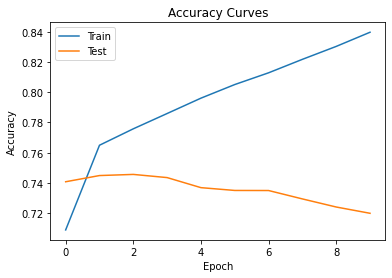

In [42]:
plt.plot(trained.history['accuracy'])
plt.plot(trained.history['val_accuracy'])
plt.title('Accuracy Curves')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

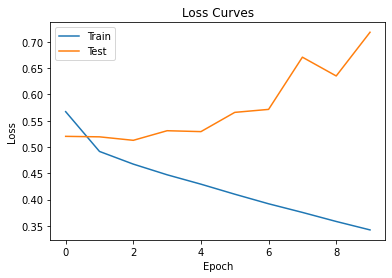

In [43]:
plt.plot(trained.history['loss'])
plt.plot(trained.history['val_loss'])
plt.title('Loss Curves')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# RNN

In [44]:
import tensorflow as tf
model = Sequential([
    layers.Embedding(5000, 100, input_length=100),
    layers.SimpleRNN(64, return_sequences=True, recurrent_dropout=0.4),
    layers.GlobalAveragePooling1D(),    # or layers.Flatten()
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

In [45]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [46]:
trained = model.fit(X_train, y_train,
                    epochs=10, 
                    validation_data=(X_val, y_val),
                    shuffle=True)

Epoch 1/10
2500/2500 [==============================] - 82s 33ms/step - loss: 0.6856 - accuracy: 0.5636 - val_loss: 0.6849 - val_accuracy: 0.5647
Epoch 2/10
2500/2500 [==============================] - 81s 32ms/step - loss: 0.6849 - accuracy: 0.5642 - val_loss: 0.6835 - val_accuracy: 0.5647
Epoch 3/10
2500/2500 [==============================] - 81s 33ms/step - loss: 0.6657 - accuracy: 0.5906 - val_loss: 0.6514 - val_accuracy: 0.6373
Epoch 4/10
2500/2500 [==============================] - 82s 33ms/step - loss: 0.6050 - accuracy: 0.6701 - val_loss: 0.5934 - val_accuracy: 0.6815
Epoch 5/10
2500/2500 [==============================] - 81s 33ms/step - loss: 0.5759 - accuracy: 0.6996 - val_loss: 0.6624 - val_accuracy: 0.6019
Epoch 6/10
2500/2500 [==============================] - 81s 32ms/step - loss: 0.5526 - accuracy: 0.7186 - val_loss: 0.5686 - val_accuracy: 0.6992
Epoch 7/10
2500/2500 [==============================] - 82s 33ms/step - loss: 0.5328 - accuracy: 0.7342 - val_loss: 0.5587 -

In [47]:
rnn = trained.history['val_accuracy']

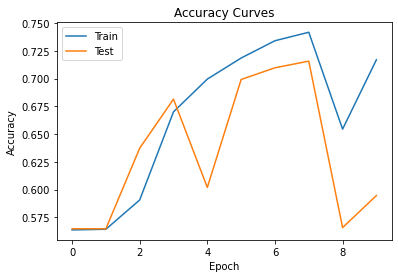

In [48]:
plt.plot(trained.history['accuracy'])
plt.plot(trained.history['val_accuracy'])
plt.title('Accuracy Curves')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

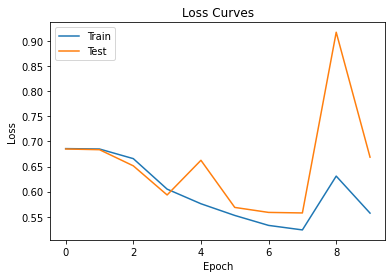

In [49]:
plt.plot(trained.history['loss'])
plt.plot(trained.history['val_loss'])
plt.title('Loss Curves')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# GRU

In [50]:
import tensorflow as tf
model = Sequential([
    layers.Embedding(5000, 100, input_length=100),
    layers.GRU(64, return_sequences=True, recurrent_dropout=0.4),
    layers.GlobalAveragePooling1D(),    # or layers.Flatten()
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

In [51]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [52]:
trained = model.fit(X_train, y_train,
                    epochs=10, 
                    validation_data=(X_val, y_val),
                    shuffle=True)

Epoch 1/10
2500/2500 [==============================] - 257s 103ms/step - loss: 0.5554 - accuracy: 0.7096 - val_loss: 0.5073 - val_accuracy: 0.7465
Epoch 2/10
2500/2500 [==============================] - 257s 103ms/step - loss: 0.4838 - accuracy: 0.7661 - val_loss: 0.5068 - val_accuracy: 0.7475
Epoch 3/10
2500/2500 [==============================] - 257s 103ms/step - loss: 0.4610 - accuracy: 0.7796 - val_loss: 0.5095 - val_accuracy: 0.7454
Epoch 4/10
2500/2500 [==============================] - 257s 103ms/step - loss: 0.4393 - accuracy: 0.7896 - val_loss: 0.5181 - val_accuracy: 0.7437
Epoch 5/10
2500/2500 [==============================] - 257s 103ms/step - loss: 0.4131 - accuracy: 0.8012 - val_loss: 0.5387 - val_accuracy: 0.7407
Epoch 6/10
2500/2500 [==============================] - 257s 103ms/step - loss: 0.3858 - accuracy: 0.8148 - val_loss: 0.5815 - val_accuracy: 0.7312
Epoch 7/10
2500/2500 [==============================] - 259s 104ms/step - loss: 0.3610 - accuracy: 0.8255 - val_

In [53]:
gru = trained.history['val_accuracy']

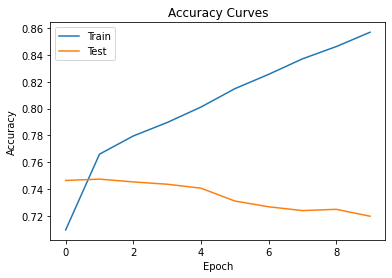

In [54]:
plt.plot(trained.history['accuracy'])
plt.plot(trained.history['val_accuracy'])
plt.title('Accuracy Curves')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

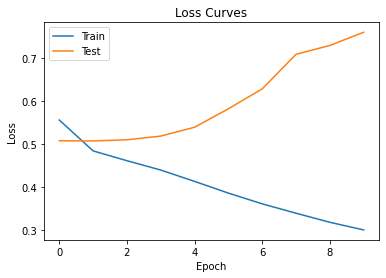

In [55]:
plt.plot(trained.history['loss'])
plt.plot(trained.history['val_loss'])
plt.title('Loss Curves')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# CNN

In [56]:
from keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
def build_cnn_model():
    model = Sequential()
    
    model.add(Embedding(5000, 100, input_length=100))


    model.add(Conv1D(64, 2, padding='same', activation='relu'))
    model.add(MaxPooling1D(2))
    #model.add(MaxPooling1D(2))
    
    model.add(Flatten())
    
    model.add(Dense(units=1024,activation="relu"))
    model.add(Dense(units=512,activation="relu"))
    
    model.add(Dense(units=num_classes,activation="softmax"))
    
    optimizer = Adam(lr=0.000055,beta_1=0.9,beta_2=0.999)
    
    model.compile(optimizer=optimizer,metrics=["accuracy"],loss=tf.keras.losses.SparseCategoricalCrossentropy())
    return model

Using TensorFlow backend.


In [57]:
cnn_model = build_cnn_model()

In [58]:
cnn_history = cnn_model.fit(X_train, y_train,
                    epochs=10, 
                    validation_data=(X_val, y_val),
                    shuffle=True)

Epoch 1/10
2500/2500 [==============================] - 8s 3ms/step - loss: 0.6855 - accuracy: 0.5646 - val_loss: 0.6848 - val_accuracy: 0.5647
Epoch 2/10
2500/2500 [==============================] - 8s 3ms/step - loss: 0.6865 - accuracy: 0.5646 - val_loss: 0.6850 - val_accuracy: 0.5647
Epoch 3/10
2500/2500 [==============================] - 8s 3ms/step - loss: 0.6845 - accuracy: 0.5656 - val_loss: 0.6848 - val_accuracy: 0.5647
Epoch 4/10
2500/2500 [==============================] - 8s 3ms/step - loss: 0.6832 - accuracy: 0.5666 - val_loss: 0.6848 - val_accuracy: 0.5647
Epoch 5/10
2500/2500 [==============================] - 8s 3ms/step - loss: 0.6827 - accuracy: 0.5671 - val_loss: 0.6844 - val_accuracy: 0.5647
Epoch 6/10
2500/2500 [==============================] - 8s 3ms/step - loss: 0.6829 - accuracy: 0.5671 - val_loss: 0.6841 - val_accuracy: 0.5645
Epoch 7/10
2500/2500 [==============================] - 8s 3ms/step - loss: 0.7244 - accuracy: 0.5675 - val_loss: 0.6853 - val_accuracy:

In [59]:
cnn = cnn_history.history['val_accuracy']

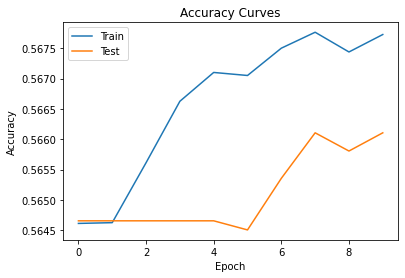

In [60]:
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title('Accuracy Curves')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

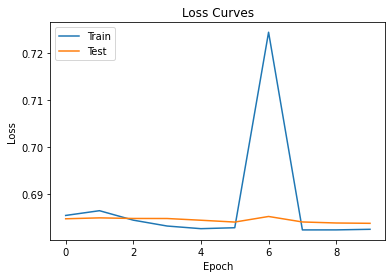

In [61]:
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('Loss Curves')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Accuracy Comparsion

In [62]:
accuracies = [LR, RF, AB, SGDA, KNNA, DT, MNB,svm,mlp,gbc,E,rnn[9],cnn[9],lstm[9],gru[9]]

In [63]:
for i in range(0, len(accuracies)):
    accuracies[i] = accuracies[i]*100
    print(accuracies[i])

76.78273782465072
76.78273782465072
71.40952207776465
75.54323120283662
65.8120435191078
69.34872867230354
75.78567748583205
56.14752856320272
73.65215019547232
71.57317331878656
77.37673121798952
59.460943937301636
56.61066174507141
71.9972014427185
71.98219895362854


In [64]:
models = ['Logistic Regression' , 'Random Forest', 'AdaBoost Classifier', 'SGD Classifier', 'KNN', 'Decision Tree', 'MNB','SVM','MLP','Gradient Boosting','Voting Classifier','RNN','CNN','LSTM','GRU']

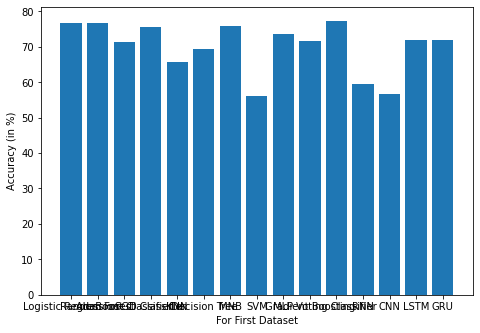

In [65]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.bar(models,accuracies)
plt.xlabel("For First Dataset")
plt.ylabel("Accuracy (in %)")
plt.show()

In [29]:
import joblib
filename = 'model.sav'
joblib.dump(ensemble, filename)

['model.sav']